# Product Purchase Prediction – Predicción de Compra de Clientes

Este proyecto tiene como objetivo predecir si un cliente realizará una compra utilizando variables de comportamiento y estacionalidad.

La idea principal es construir un modelo **simple, interpretable y fácil de explicar en una entrevista técnica**.

---

## Objetivo del proyecto

Desarrollar un modelo capaz de anticipar la probabilidad de compra de un cliente para apoyar decisiones de marketing, segmentación y campañas estacionales.

---


## 1. Importación de librerías

En esta sección importamos las herramientas necesarias para:

- Manipular datos
- Generar un dataset sintético
- Visualizar relaciones entre variables
- Entrenar el modelo
- Evaluar resultados

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, ConfusionMatrixDisplay

import pickle

# Fijamos una semilla para que los resultados sean reproducibles.
# Esto es importante porque permite que otra persona ejecute el notebook y obtenga resultados similares.
np.random.seed(42)

## 2. Generación del dataset sintético

Como no estamos usando datos reales de una empresa, generamos un dataset sintético de **5,000 registros**.

El dataset simula un escenario de negocio donde queremos saber si un cliente comprará o no.

### Variables utilizadas

- `Is_Winter`: indica si el cliente está en temporada de invierno.
- `Is_Holiday_Season`: indica si es temporada de festivos o promociones.
- `Days_Since_Last_Purchase`: días desde la última compra del cliente.
- `Average_Spend`: gasto promedio del cliente.
- `Made_Purchase`: variable objetivo. Indica si el cliente compró o no.

In [9]:
n = 5000

# Creamos variables simples y fáciles de explicar.
data = pd.DataFrame({
    "Is_Winter": np.random.binomial(1, 0.30, n),
    "Is_Holiday_Season": np.random.binomial(1, 0.25, n),
    "Days_Since_Last_Purchase": np.random.randint(1, 60, n),
    "Average_Spend": np.random.normal(100, 30, n)
})

# Evitamos valores negativos en Average_Spend, ya que no tendría sentido para gasto promedio.
data["Average_Spend"] = data["Average_Spend"].clip(lower=5)

# Creamos una relación lógica entre las variables y la probabilidad de compra.
# Esta fórmula simula un comportamiento realista:
# - Invierno aumenta la probabilidad de compra.
# - Temporada de festivos aumenta aún más la probabilidad.
# - Más días desde la última compra reduce la probabilidad.
# - Mayor gasto promedio aumenta la probabilidad.
logits = (
    1.5 * data["Is_Winter"] +
    2.0 * data["Is_Holiday_Season"] -
    0.03 * data["Days_Since_Last_Purchase"] +
    0.02 * data["Average_Spend"] -
    3
)

# Convertimos los logits a probabilidades usando la función sigmoide.
probabilities = 1 / (1 + np.exp(-logits))

# Generamos la variable objetivo.
data["Made_Purchase"] = np.random.binomial(1, probabilities)

# Guardamos el dataset como CSV para simular un flujo real de trabajo.
data.to_csv("purchase_data.csv", index=False)

# Mostramos las primeras filas.
data.head()

,Is_Winter,Is_Holiday_Season,Days_Since_Last_Purchase,Average_Spend,Made_Purchase
0,0,0,55,115.130952,0
1,1,0,32,83.761027,0
2,1,1,36,40.695353,0
3,0,0,50,85.143547,0
4,0,1,37,90.869654,1


## 3. Carga de datos

Aunque acabamos de generar el CSV, lo cargamos nuevamente desde archivo para simular un flujo real de proyecto.

Esto permite que el notebook muestre claramente el paso de **carga de datos**, como se haría con un dataset real.

In [10]:
df = pd.read_csv("purchase_data.csv")
df.head()

,Is_Winter,Is_Holiday_Season,Days_Since_Last_Purchase,Average_Spend,Made_Purchase
0,0,0,55,115.130952,0
1,1,0,32,83.761027,0
2,1,1,36,40.695353,0
3,0,0,50,85.143547,0
4,0,1,37,90.869654,1


## 4. Revisión inicial del dataset

Antes de entrenar cualquier modelo, revisamos la estructura del dataset.

In [11]:
print("Shape del dataset:", df.shape)
print("\nInformación general:")
df.info()

Shape del dataset: (5000, 5)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Is_Winter                 5000 non-null   int64  
 1   Is_Holiday_Season         5000 non-null   int64  
 2   Days_Since_Last_Purchase  5000 non-null   int64  
 3   Average_Spend             5000 non-null   float64
 4   Made_Purchase             5000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 195.4 KB


In [12]:
print("Valores nulos por columna:")
df.isnull().sum()

Valores nulos por columna:


,0
Is_Winter,0
Is_Holiday_Season,0
Days_Since_Last_Purchase,0
Average_Spend,0
Made_Purchase,0


In [13]:
print("Distribución de la variable objetivo:")
df["Made_Purchase"].value_counts(normalize=True).rename("Proportion")

Distribución de la variable objetivo:


,Proportion
Made_Purchase,
0,0.6804
1,0.3196


### Observación

La variable objetivo `Made_Purchase` representa si el cliente compró o no.

Es importante revisar su distribución porque, si una clase domina demasiado, métricas como Accuracy pueden ser engañosas.

En este proyecto usamos Accuracy y Precision porque queremos mantener la evaluación simple y fácil de explicar.

## 5. Estadísticas descriptivas

Revisamos estadísticas básicas para entender los rangos y comportamiento de las variables numéricas.

In [14]:
df.describe()

,Is_Winter,Is_Holiday_Season,Days_Since_Last_Purchase,Average_Spend,Made_Purchase
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.294000,0.235200,29.921800,100.283306,0.319600
std,0.455637,0.424166,17.007667,29.938984,0.466368
min,0.000000,0.000000,1.000000,5.000000,0.000000
25%,0.000000,0.000000,15.000000,80.168479,0.000000
50%,0.000000,0.000000,30.000000,100.259406,0.000000
75%,1.000000,0.000000,45.000000,120.205415,1.000000
max,1.000000,1.000000,59.000000,202.867314,1.000000


### Observación

- `Days_Since_Last_Purchase` tiene valores entre 1 y 59 días.
- `Average_Spend` representa el gasto promedio del cliente.
- Las variables `Is_Winter` e `Is_Holiday_Season` son binarias.

Este tipo de dataset es ideal para explicar un modelo interpretable durante una entrevista.

## 6. Análisis exploratorio de datos (EDA)

Ahora analizamos visualmente cómo se relacionan las variables con la compra.

El objetivo no es hacer gráficos complejos, sino obtener insights fáciles de comunicar.

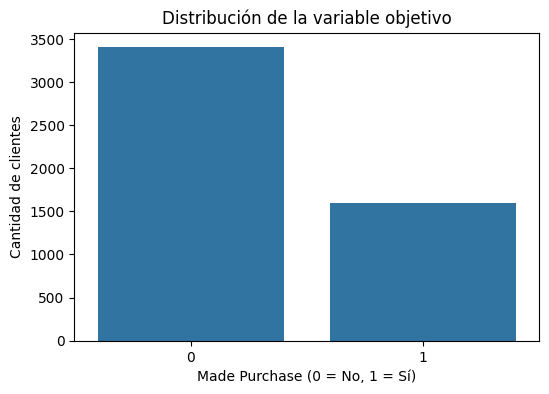

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Made_Purchase")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Made Purchase (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de clientes")
plt.show()

### Observación

Este gráfico nos muestra cuántos clientes compraron y cuántos no.

In [16]:
purchase_by_winter = df.groupby("Is_Winter")["Made_Purchase"].mean().reset_index()
purchase_by_winter

,Is_Winter,Made_Purchase
0,0,0.241076
1,1,0.508163


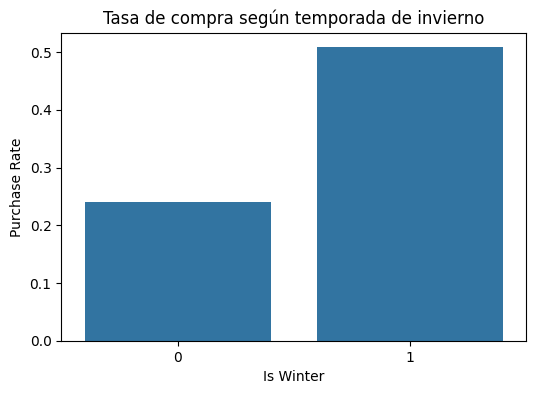

In [17]:
plt.figure(figsize=(6, 4))
sns.barplot(data=purchase_by_winter, x="Is_Winter", y="Made_Purchase")
plt.title("Tasa de compra según temporada de invierno")
plt.xlabel("Is Winter")
plt.ylabel("Purchase Rate")
plt.show()

### Observación

Si la tasa de compra es mayor cuando `Is_Winter = 1`, significa que la temporada de invierno podría estar asociada con mayor intención de compra.

In [18]:
purchase_by_holiday = df.groupby("Is_Holiday_Season")["Made_Purchase"].mean().reset_index()
purchase_by_holiday

,Is_Holiday_Season,Made_Purchase
0,0,0.235617
1,1,0.592687


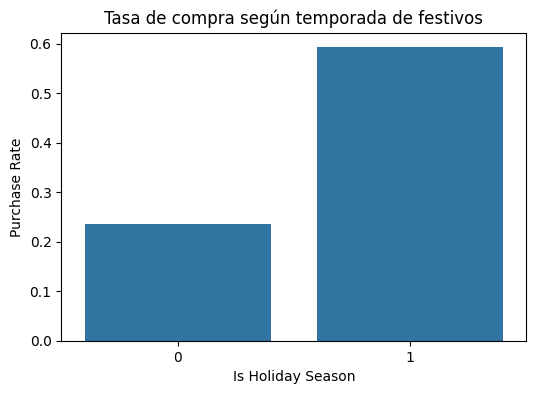

In [19]:
plt.figure(figsize=(6, 4))
sns.barplot(data=purchase_by_holiday, x="Is_Holiday_Season", y="Made_Purchase")
plt.title("Tasa de compra según temporada de festivos")
plt.xlabel("Is Holiday Season")
plt.ylabel("Purchase Rate")
plt.show()

### Observación

La temporada de festivos suele ser un factor fuerte en decisiones de compra.



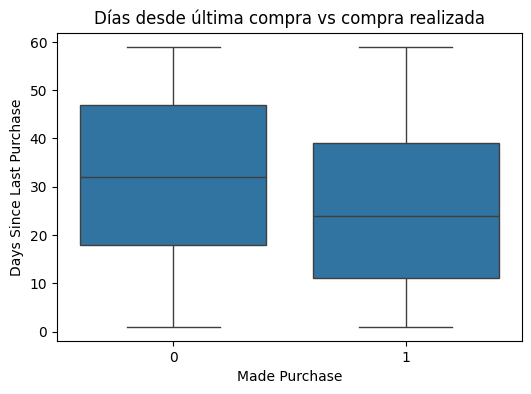

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Made_Purchase", y="Days_Since_Last_Purchase")
plt.title("Días desde última compra vs compra realizada")
plt.xlabel("Made Purchase")
plt.ylabel("Days Since Last Purchase")
plt.show()

### Observación

Clientes con menos días desde su última compra pueden estar más activos o comprometidos con la marca.

Por eso esperamos que `Days_Since_Last_Purchase` tenga un efecto negativo: mientras más días pasan, menor puede ser la probabilidad de compra.

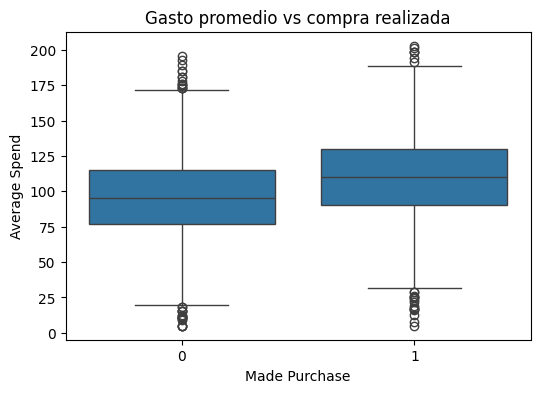

In [21]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Made_Purchase", y="Average_Spend")
plt.title("Gasto promedio vs compra realizada")
plt.xlabel("Made Purchase")
plt.ylabel("Average Spend")
plt.show()

### Observación

Si los compradores tienen un gasto promedio mayor, esta variable puede ser útil para predecir compras futuras.

## 7. Correlation Heatmap

La matriz de correlación permite ver relaciones lineales entre las variables.

No reemplaza el modelo, pero ayuda a detectar patrones iniciales.

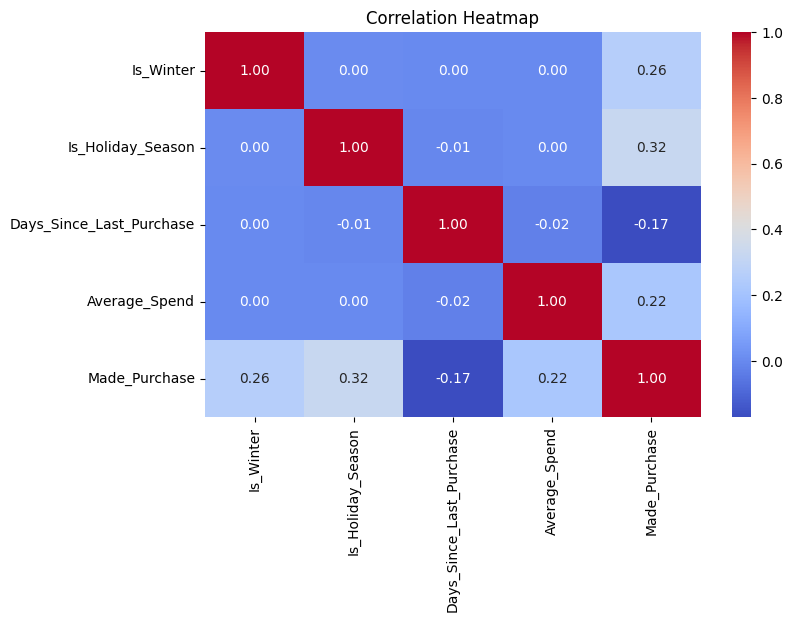

In [22]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Observación

La correlación ayuda a identificar qué variables tienen mayor relación con `Made_Purchase`.


## 8. Separación de variables predictoras y variable objetivo

Definimos:

- `X`: variables que usará el modelo para aprender.
- `y`: variable objetivo que queremos predecir.

In [23]:
X = df.drop("Made_Purchase", axis=1)
y = df["Made_Purchase"]

X.head()

,Is_Winter,Is_Holiday_Season,Days_Since_Last_Purchase,Average_Spend
0,0,0,55,115.130952
1,1,0,32,83.761027
2,1,1,36,40.695353
3,0,0,50,85.143547
4,0,1,37,90.869654


## 9. Train/Test Split

Dividimos el dataset en entrenamiento y prueba.

- Entrenamiento: el modelo aprende patrones.
- Prueba: evaluamos cómo se comporta con datos no vistos.

Esto simula un escenario real donde el modelo se usa con nuevos clientes.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (4000, 4)
Tamaño de prueba: (1000, 4)


## 10. Entrenamiento del modelo: Logistic Regression

Usamos **Logistic Regression** porque este proyecto está diseñado para ser explicable.

### ¿Por qué no usar un modelo más complejo?

Porque el objetivo de este proyecto es demostrar interpretación y comunicación.

Un modelo como Random Forest puede tener mejor rendimiento en algunos casos, pero es más difícil explicar el impacto directo de cada variable.



In [25]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 11. Evaluación del modelo

En un contexto de marketing, Precision es útil porque ayuda a reducir campañas enviadas a clientes que probablemente no comprarán.

In [26]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")

Accuracy: 0.7590
Precision: 0.6820


### Observación

- Un Accuracy alto indica que el modelo acierta una buena proporción del total.
- Una Precision alta indica que, cuando el modelo predice compra, suele tener razón.



## 12. Matriz de confusión

La matriz de confusión nos ayuda a entender los errores del modelo en lenguaje simple.

- **True Negative**: el modelo predijo que no compraría y no compró.
- **False Positive**: el modelo predijo que compraría, pero no compró.
- **False Negative**: el modelo predijo que no compraría, pero sí compró.
- **True Positive**: el modelo predijo que compraría y sí compró.

In [27]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[611,  69],
       [172, 148]])

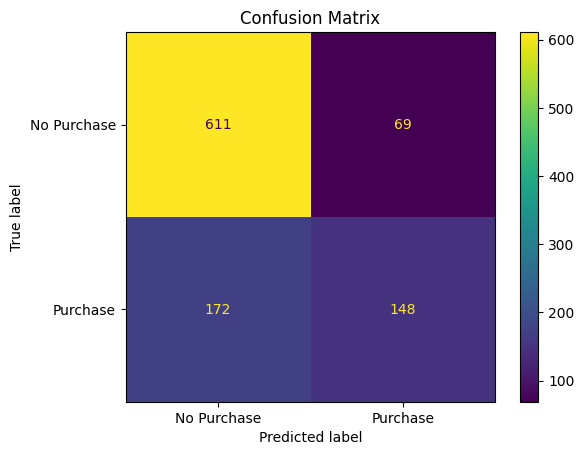

In [28]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Purchase", "Purchase"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [29]:
tn, fp, fn, tp = cm.ravel()

print(f"El modelo predijo correctamente {tp} compradores.")
print(f"El modelo predijo correctamente {tn} no compradores.")
print(f"El modelo se equivocó en {fp} casos donde predijo compra, pero el cliente no compró.")
print(f"El modelo perdió {fn} compradores reales, prediciendo que no comprarían.")

El modelo predijo correctamente 148 compradores.
El modelo predijo correctamente 611 no compradores.
El modelo se equivocó en 69 casos donde predijo compra, pero el cliente no compró.
El modelo perdió 172 compradores reales, prediciendo que no comprarían.


### Explicación en lenguaje de negocio

La matriz de confusión no solo muestra si el modelo acierta o falla. También muestra **qué tipo de error comete**.

Para marketing:

- Un **False Positive** puede significar gastar presupuesto en un cliente que no compra.
- Un **False Negative** puede significar perder la oportunidad de contactar a un cliente que sí iba a comprar.

## 13. Interpretación de coeficientes


In [30]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
coefficients

,Feature,Coefficient
1,Is_Holiday_Season,1.870766
0,Is_Winter,1.426153
3,Average_Spend,0.020525
2,Days_Since_Last_Purchase,-0.028399


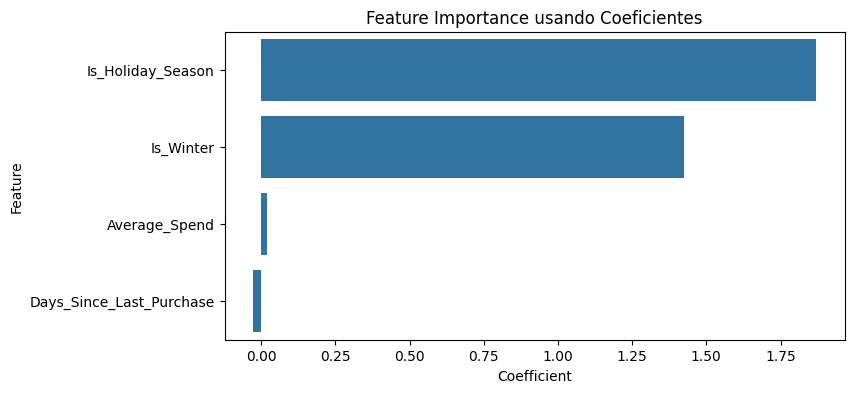

In [31]:
plt.figure(figsize=(8, 4))
sns.barplot(data=coefficients, x="Coefficient", y="Feature")
plt.title("Feature Importance usando Coeficientes")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

### Observación

Este gráfico permite explicar qué variables influyen más en la decisión del modelo.

## 14. Odds Ratio

Los coeficientes de Logistic Regression están en log-odds, lo cual puede ser difícil de explicar.

Por eso convertimos los coeficientes a **Odds Ratios** usando `exp(coefficient)`.

### Cómo interpretarlo

- Odds Ratio mayor que 1: aumenta la probabilidad de compra.
- Odds Ratio menor que 1: disminuye la probabilidad de compra.
- Odds Ratio igual a 1: casi no cambia la probabilidad.

In [32]:
coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])
coefficients

,Feature,Coefficient,Odds_Ratio
1,Is_Holiday_Season,1.870766,6.493271
0,Is_Winter,1.426153,4.162654
3,Average_Spend,0.020525,1.020737
2,Days_Since_Last_Purchase,-0.028399,0.972000


## 15. Predicción para un cliente nuevo

Ahora probamos el modelo con un ejemplo simple.

Cliente hipotético:

- Está en invierno.
- Está en temporada de festivos.
- Compró hace 10 días.
- Tiene gasto promedio de 150.

In [33]:
new_customer = pd.DataFrame({
    "Is_Winter": [1],
    "Is_Holiday_Season": [1],
    "Days_Since_Last_Purchase": [10],
    "Average_Spend": [150]
})

prediction = model.predict(new_customer)[0]
probability = model.predict_proba(new_customer)[0][1]

print("Predicción:", "Compra" if prediction == 1 else "No compra")
print(f"Probabilidad estimada de compra: {probability:.2%}")

Predicción: Compra
Probabilidad estimada de compra: 95.47%


### Observación

Este paso es útil para entrevistas porque demuestra cómo el modelo se puede usar en un caso real.



## 16. Guardado del modelo

Guardamos el modelo entrenado para poder reutilizarlo en una aplicación, por ejemplo con Streamlit.

In [34]:
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Modelo guardado como model.pkl")

Modelo guardado como model.pkl


## 17. Conclusiones

### Hallazgos principales

- La temporada de festivos tiene un impacto positivo fuerte en la probabilidad de compra.
- La temporada de invierno también aumenta la probabilidad de compra.
- Más días desde la última compra reduce la probabilidad de que un cliente compre.
- Clientes con mayor gasto promedio tienden a tener mayor probabilidad de compra.

### Valor de negocio

Este modelo puede ayudar a:

- Priorizar clientes para campañas.
- Optimizar presupuesto de marketing.
- Identificar temporadas con mayor potencial de venta.
- Explicar decisiones del modelo a equipos no técnicos.

---